In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram


In [2]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42,
)

In [3]:
X

array([[-8.55503989,  7.06461794],
       [-6.13753182, -6.58081701],
       [-6.32130028, -6.8041042 ],
       ...,
       [ 3.69047995,  4.60555175],
       [-7.48913939, -7.0670809 ],
       [-9.40049578,  7.11430104]], shape=(1000, 2))

<Axes: >

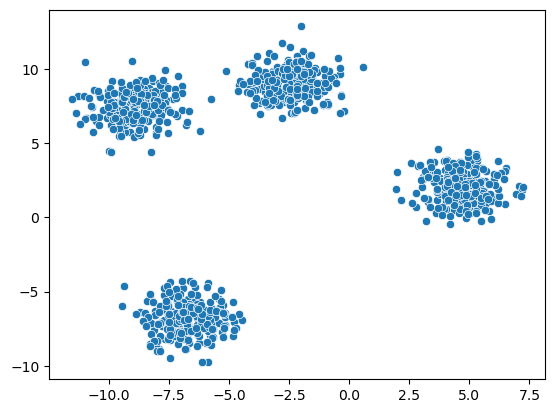

In [4]:
# visualize
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
)

In [5]:
# scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
# model training
K = 4
km_model = KMeans(
    n_clusters=K,
    init='random',
    random_state=42
)


In [7]:
labels = km_model.fit_predict(X)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


<Axes: >

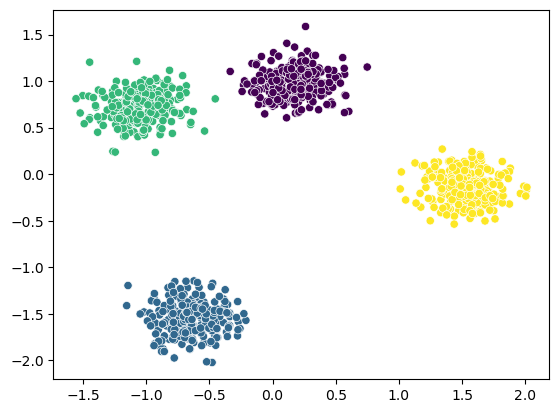

In [8]:
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    c=labels
)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

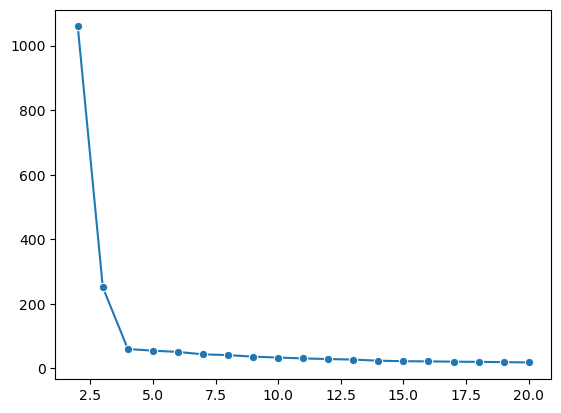

In [9]:
# Choose K value
# Elbow method
ks = range(2, 21)
wcss = []
for K in ks:
    km_model = KMeans(
        n_clusters=K,
        random_state=42
    )
    km_model.fit_predict(X)
    wcss.append(km_model.inertia_)


sns.lineplot(
    x=ks,
    y=wcss,
    marker="o"
)
    

In [10]:
! pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [11]:
from kneed import KneeLocator

In [12]:
knee_locator = KneeLocator(
    ks,
    wcss,
    curve="convex", 
    direction="decreasing"
)
knee_locator.elbow

np.int64(4)

In [13]:
# Silhouette score
ss = []
for K in ks:
    km_model = KMeans(
        n_clusters=K,
        random_state=42
    )
    labels = km_model.fit_predict(X)
    ss.append(silhouette_score(X, labels))


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [14]:
count = 2
for s in ss:
    print(f"{count} => {s}")
    count += 1

2 => 0.5552764027792548
3 => 0.7376805979502701
4 => 0.7982504226478482
5 => 0.6614327766277438
6 => 0.5395226651582832
7 => 0.4552345981835933
8 => 0.450884871689894
9 => 0.3268294942657242
10 => 0.3304731833237556
11 => 0.32777615719177144
12 => 0.3365285723376163
13 => 0.333981713562382
14 => 0.3396834741542724
15 => 0.33892768259765854
16 => 0.3324462346488036
17 => 0.32572369802508394
18 => 0.3198833074827515
19 => 0.32093625932540537
20 => 0.3126628367379426


In [22]:
print("Silhoutte Score:", silhouette_score(X, labels))
print("Davies Bouldin Score:", davies_bouldin_score(X, labels))
print("Adjust rand score:", adjusted_rand_score(labels_true=y, labels_pred=labels))

Silhoutte Score: 0.7376805979502701
Davies Bouldin Score: 0.37612634760030333
Adjust rand score: 0.7136715391229579


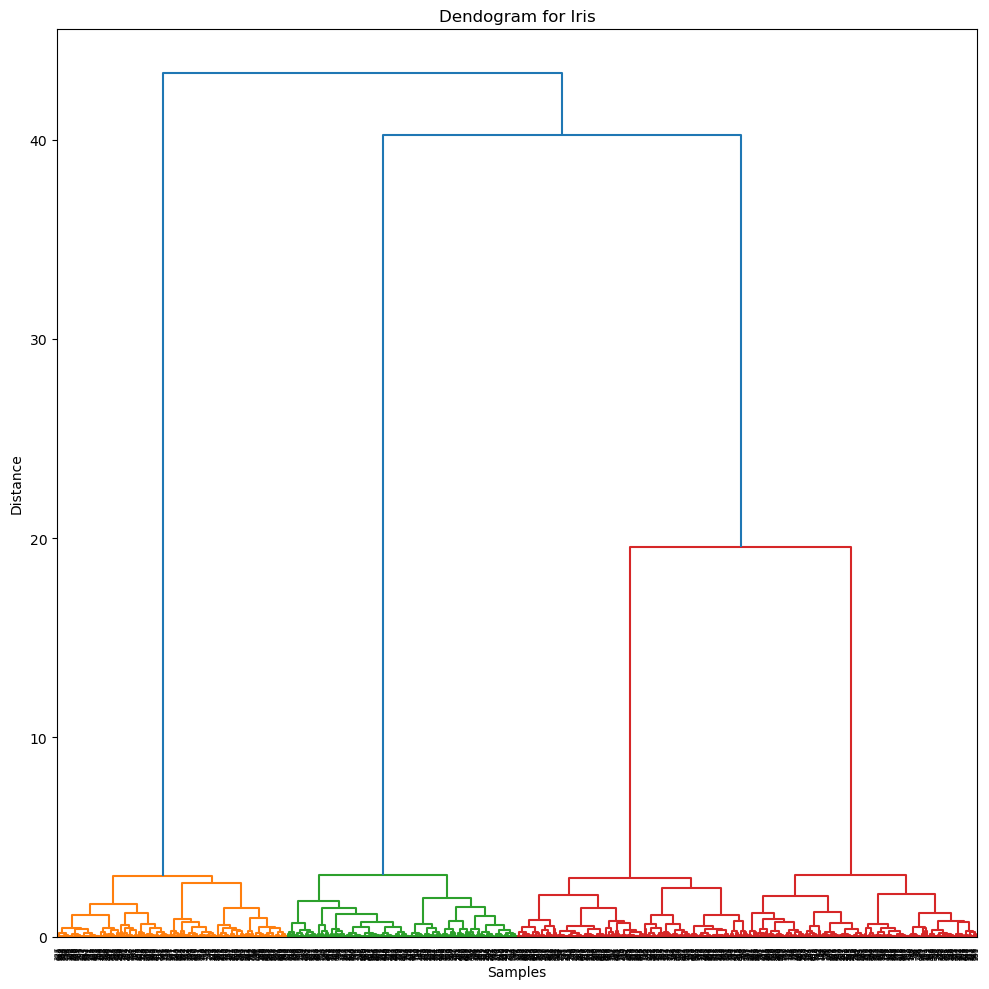

In [16]:
# Agglomerative Clustering
Z = linkage(X, method="ward")
plt.figure(figsize=(10, 10))
dendrogram(Z)
plt.title("Dendogram for Iris")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()


In [17]:
ac_model = AgglomerativeClustering(
    n_clusters=3
)
labels = ac_model.fit_predict(X)

<Axes: >

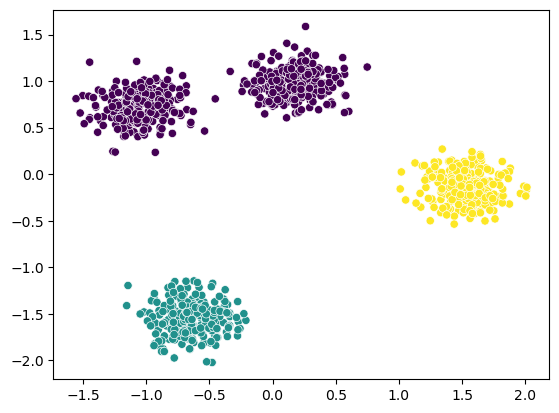

In [18]:
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    c=labels
)